In [93]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import argparse
from scipy.optimize import minimize, OptimizeResult, basinhopping

from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.circuit import Parameter
from qiskit.circuit.library import PauliEvolutionGate, CXGate
from qiskit.converters import dag_to_circuit, circuit_to_dag
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import InverseCancellation, CommutativeCancellation


from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping
from qopt_best_practices.transpilation.qaoa_construction_pass import QAOAConstructionPass

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration

from qiskit_qaoa.utils.commuting_gate_router import CommutingGateRouter
from qiskit_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.hubo.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy, FindCommutingPauliEvolutionsMulti
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples


In [94]:
with open('/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise/basinhopping.test_N2_W2.p1.pkl', 'rb') as f:
    res = pickle.load(f)

In [95]:
res.keys()

dict_keys(['result', 'history', 't_qaoa_circ', 'hamiltonian'])

In [96]:
res['result'].x

array([0.78188822, 0.490074  ])

In [98]:

def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')
    



filename: str = 'test_N2_W2'
p: int = 1
N: int = 2
T: int = 2
copy_numbers: list[float] = [1,1]
n = int(np.ceil(np.log2(2*N+1)))

seed = 1
rng = np.random.default_rng()

basis_gates=["sx", "x", "rz", "rzz", "cz", "id", "swap", "cx", "h"]


extended_swap_strat = ExtendedSwapStrategy.from_all_to_all(n * T)

num_physical_qubits = extended_swap_strat._num_vertices
coupling_map = extended_swap_strat._coupling_map

backend_options = dict(
    method='statevector',
    device='CPU',
    precision='single',
    basis_gates=basis_gates,
)

config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = num_physical_qubits
config["basis_gates"] = basis_gates
config = AerBackendConfiguration.from_dict(config)
backend = AerSimulator(configuration=config, coupling_map=extended_swap_strat._coupling_map, **backend_options)
backend.set_option("n_qubits", num_physical_qubits)
print(f'Num qubits in backend: {backend.configuration().to_dict()["n_qubits"]}')


filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)

full_hamiltonian = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
num_qubits = n * T



pm_rz = PassManager(
    [
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
            max_layers=0,
            perform_extra_swaps=True
        ),
        SwapToFinalMapping(),
        InverseCancellation(gates_to_cancel=[CXGate()]),
        CommutativeCancellation(basis_gates=["cx", "swap", "rz", "rzz"]),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)
qc = QuantumCircuit(num_physical_qubits)
qc.append(PauliEvolutionGate(full_hamiltonian, time=Parameter("c")), range(num_physical_qubits))   
tqc_rz = pm_rz.run(qc)
print_circuit_info(tqc_rz, 'Transpiled cost hamiltonian circuit')
print(tqc_rz.count_ops())
print(f'Cost hamiltonian circuit has {tqc_rz.num_qubits} qubits')


construction_pass = QAOAConstructionPass(p)
t_qaoa_circ = dag_to_circuit(construction_pass.run(circuit_to_dag(tqc_rz)))
t_qaoa_circ.remove_final_measurements()

Num qubits in backend: 6
Keeping constraints at times: [0]
Max layers needed to apply swap decompose: 0
Gates we cannot directly implement: 0
[]
Transpiling accumulator
Transpiled cost hamiltonian circuit has 52 2Q gates     and 40 2Q depth
OrderedDict([('cx', 52), ('rz', 31)])
Cost hamiltonian circuit has 6 qubits
layout not found, assigining trivial layout


In [99]:
keys = [np.binary_repr(x, num_physical_qubits) for x in range(2**num_physical_qubits)]


In [100]:
assigned_circuit = t_qaoa_circ.assign_parameters(res['result'].x, inplace=False)
assigned_circuit.save_statevector()
job = backend.run([assigned_circuit])
result = job.result()
data = result.results[0].data
sv = np.asarray(data.statevector)

evals = evaluate_sparse_pauli_samples(keys, full_hamiltonian)
energy = np.sum(np.abs(sv) ** 2 * evals)

In [101]:
from collections import Counter
Counter(evals)

Counter({np.float64(1.0): 16,
         np.float64(11.0): 16,
         np.float64(2.0): 16,
         np.float64(12.0): 8,
         np.float64(10.0): 6,
         np.float64(0.0): 2})

In [102]:
# 1.0: (000 or 100 or 010 or 110) * (001 or 101 or 011 or 111)
# 2.0 (001 or 101 or 011 or 111) * (001 or 101 or 011 or 111)

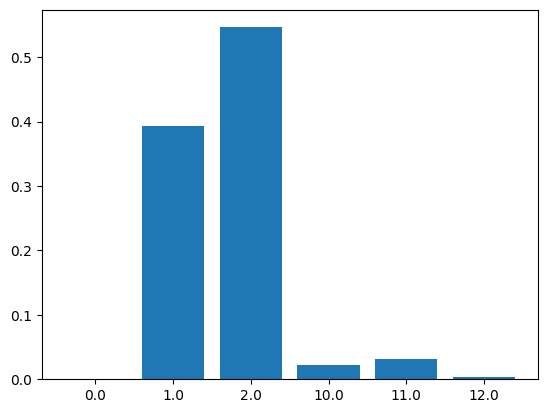

In [103]:
evals_set = list(set(evals))
bars = {eval: 0 for eval in evals_set}
for x in range(len(sv)):
    bars[evals[x]] += np.abs(sv[x]) ** 2
plt.bar(np.arange(len(evals_set)), bars.values())
plt.xticks(np.arange(len(evals_set)), evals_set)
print()

In [104]:
# evals, amplitudes, labels, = zip(*sorted(zip(
#     evals, np.abs(sv) ** 2, np.array([np.binary_repr(x, num_physical_qubits) for x in range(2**num_physical_qubits)])
# )))
# amplitudes = np.array(amplitudes)
# labels = np.array(labels)

In [105]:
# plt.bar(labels, amplitudes)
# tick_locations = [x for x in range(len(evals) - 1) if not evals[x] ==  evals[x+1] ]
# plt.xticks(tick_locations, [evals[y] for y in tick_locations], rotation=90)
# print()

In [106]:
assigned_circuit = t_qaoa_circ.assign_parameters(res['history'][230][1], inplace=False)
assigned_circuit.save_statevector()
job = backend.run([assigned_circuit])
result = job.result()
data = result.results[0].data
sv = np.asarray(data.statevector)
evals = evaluate_sparse_pauli_samples(keys, full_hamiltonian)
energy = np.sum(np.abs(sv) ** 2 * evals)


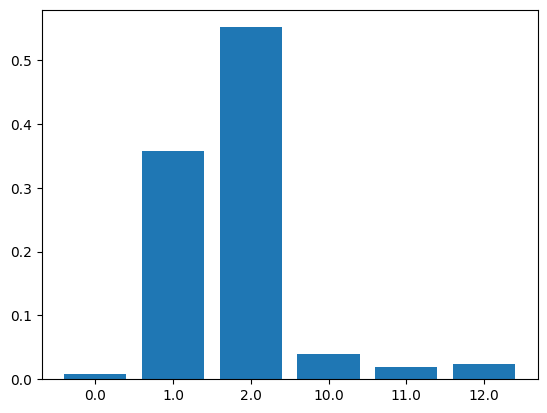

In [107]:
evals_set = list(set(evals))
bars = {eval: 0 for eval in evals_set}
for x in range(len(sv)):
    bars[evals[x]] += np.abs(sv[x]) ** 2
plt.bar(np.arange(len(evals_set)), bars.values())
plt.xticks(np.arange(len(evals_set)), evals_set)
print()

In [108]:
# evals, amplitudes, labels, = zip(*sorted(zip(
#     evals, np.abs(sv) ** 2, np.array([np.binary_repr(x, num_physical_qubits) for x in range(2**num_physical_qubits)])
# )))
# amplitudes = np.array(amplitudes)
# labels = np.array(labels)

# plt.bar(labels, amplitudes)
# tick_locations = [x for x in range(len(evals) - 1) if not evals[x] ==  evals[x+1] ]
# plt.xticks(tick_locations, [evals[y] for y in tick_locations], rotation=90)
# print()

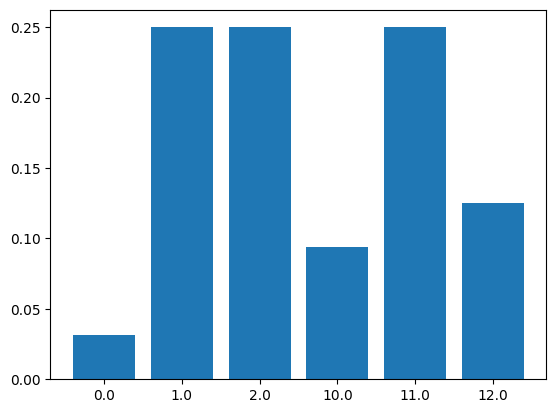

In [109]:
assigned_circuit = t_qaoa_circ.assign_parameters([0,0], inplace=False)
assigned_circuit.save_statevector()
job = backend.run([assigned_circuit])
result = job.result()
data = result.results[0].data
sv = np.asarray(data.statevector)
evals = evaluate_sparse_pauli_samples(keys, full_hamiltonian)
energy = np.sum(np.abs(sv) ** 2 * evals)

evals_set = list(set(evals))
bars = {eval: 0 for eval in evals_set}
for x in range(len(sv)):
    bars[evals[x]] += np.abs(sv[x]) ** 2
plt.bar(np.arange(len(evals_set)), bars.values())
plt.xticks(np.arange(len(evals_set)), evals_set)
print()

In [110]:
bars

{np.float64(0.0): np.float64(0.031249992549419847),
 np.float64(1.0): np.float64(0.24999994039535878),
 np.float64(2.0): np.float64(0.24999994039535878),
 np.float64(10.0): np.float64(0.09374997764825954),
 np.float64(11.0): np.float64(0.24999994039535878),
 np.float64(12.0): np.float64(0.12499997019767939)}